# Alpha Visualization on BondSim Output

This notebook loads synthetic trades from BondSim (same workflow as `bondsim_demo.ipynb`), computes the implemented standalone alphas **A1–A6** and **A16**, and visualizes each with **seaborn**.

The simulator plants three positive controls. The alphas below are the public-feature views researchers can use to detect them:

| Alpha | Name | Primary trace feature | Planted control |
|---|---|---|---|
| A1 | RFQ / TRACE count imbalance | `a1_trace_side_valid_last_10_count_imbalance` | sign persistence |
| A2 | Notional imbalance | `a2_trace_side_valid_last_10_raw_notional_imbalance` | large-print reversal |
| A3 | Buy/sell intensity | `a3_trace_2h_log_intensity_ratio` | sign persistence |
| A4 | Last-side persistence | `a4_trace_last_10_fraction_same_as_last` | sign persistence |
| A5 | Activity surprise | `a5_trace_2h_event_count_surprise` | Hawkes clustering |
| A6 | Spread-conditioned flow | `a6_trace_last_5_flow_pressure` | flow pressure |
| A16 | RFQ scarcity / disagreement | RFQ-only fields | requires RFQ tape |

Truth columns are used only for oracle overlays (dashed reference lines, hue labels). Alpha code never reads truth in production.

Run from `bond_alpha`:

```bash
conda activate MechanicalAlpha
cd bond_alpha
jupyter notebook notebooks/alpha_visualization.ipynb
```

In [1]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

warnings.filterwarnings("ignore", category=DeprecationWarning)

NOTEBOOK_DIR = Path.cwd().resolve()
BOND_ALPHA_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
SRC_ROOT = BOND_ALPHA_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))
os.chdir(BOND_ALPHA_ROOT)

from bondsim.activity import daily_activity_multipliers, session_calendar
from bondsim.config import load_config
from bondsim.hawkes.graph import build_hawkes_graph
from bondsim.hawkes.simulate import simulate_session_clock
from bondsim.marks.fallback import EmpiricalMarkSampler
from bondsim.prices.engine import PriceEngine
from bondsim.scenarios import flags_for
from bondsim.schema import PUBLIC_TRADE_COLUMNS, TRUTH_COLUMNS
from bondsim.universe import build_universe
from bondsim.utils.seeds import SeedBank

from mechanical_alpha.alphas import (
    A1_rfq_count_imbalance,
    A2_rfq_notional_imbalance,
    A3_buy_sell_intensity,
    A4_last_side_persistence,
    A5_activity_surprise,
    A6_spread_conditioned_flow,
    A16_rfq_scarcity_disagreement,
)
from mechanical_alpha.contracts import FieldStatus, SourceMetadata
from mechanical_alpha.data.bundle import bundle_from_frames
from mechanical_alpha.data.synthetic import _canonicalize_synthetic_bonds, _canonicalize_synthetic_events
from mechanical_alpha.registry import ALPHA_INDEX
from mechanical_alpha.schema import Availability, SideConvention

PALETTE = sns.color_palette("colorblind")
sns.set_theme(style="whitegrid", palette=PALETTE, context="notebook")
FIGSIZE_WIDE = (11, 4)
HORIZON = pd.Timedelta("4h")
MAX_EVENTS_FOR_ALPHA = 1200

print(f"Working directory: {BOND_ALPHA_ROOT}")
print("Registered alphas:", ", ".join(item.alpha_id for item in ALPHA_INDEX))

Working directory: /media/ak/10E1026C4FA6006E/GitRepos/MechanicalAlpha/bond_alpha
Registered alphas: A1, A2, A3, A4, A5, A6, A16


## Load BondSim public trades and truth

By default we run a compact in-notebook simulation (fast, no marketdb).
Set `USE_MEDIUM_RUN = True` to load the pre-generated medium scenario instead (subsampled for speed).

In [2]:
USE_MEDIUM_RUN = False
MEDIUM_SCENARIO_ROOT = BOND_ALPHA_ROOT / "data/medium/seed=20260834/synthetic/scenario=controlled_all"
MEDIUM_TRUTH_ROOT = BOND_ALPHA_ROOT / "data/medium/seed=20260834/synthetic_truth/scenario=controlled_all"


def read_partitioned_parquet(root: Path) -> pd.DataFrame:
    import duckdb

    pattern = str(root / "year=*/month=*/part-*.parquet")
    files = sorted(root.glob("year=*/month=*/part-*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet partitions under {root}")
    return duckdb.read_parquet(pattern).df()


def read_parquet_file(path: Path) -> pd.DataFrame:
    import duckdb

    return duckdb.read_parquet(str(path)).df()


def synthetic_training_events(n_rows: int = 500) -> pd.DataFrame:
    rng = np.random.default_rng(42)
    notionals = rng.lognormal(mean=12.5, sigma=0.8, size=n_rows)
    sides = rng.choice([1, -1], size=n_rows)
    return pd.DataFrame(
        {
            "side": sides,
            "notional": notionals,
            "is_interdealer": rng.choice([True, False], size=n_rows, p=[0.35, 0.65]),
            "trade_type": "customer",
            "venue": "unknown",
            "reporting_delay_ms": rng.exponential(250.0, size=n_rows),
            "log_notional": np.log1p(notionals),
        }
    )


def run_mini_simulation(scenario_name: str, n_sessions: int = 12) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    config = load_config("configs/controlled_all.yaml")
    seed_bank = SeedBank.create(config.project.master_seed)
    universe = build_universe(pd.DataFrame(), config, seed_bank.rng("universe"), "smoke")
    scenario_flags = flags_for(scenario_name)
    hawkes_graph = build_hawkes_graph(universe, config, scenario_flags)
    mark_sampler = EmpiricalMarkSampler(synthetic_training_events())
    price_engine = PriceEngine(universe, config, scenario_flags, seed_bank.rng("ou"))
    sessions = session_calendar("2026-01-02", n_sessions)
    activity = daily_activity_multipliers(n_sessions, seed_bank.rng("activity"))
    public_rows: list[dict[str, object]] = []
    truth_rows: list[dict[str, object]] = []
    immigrant_rng = seed_bank.rng("hawkes_immigrants")
    offspring_rng = seed_bank.rng("hawkes_offspring")
    mark_rng = seed_bank.rng("marks")
    for session_idx, session in enumerate(sessions):
        session_clock = simulate_session_clock(
            universe,
            hawkes_graph,
            session_idx,
            float(activity[session_idx]),
            immigrant_rng,
            offspring_rng,
            config.simulation.max_events_per_session_safety,
        )
        for event_idx, clock_event in enumerate(session_clock):
            event_id = f"{scenario_name}_{session_idx:04d}_{event_idx:06d}"
            mark = mark_sampler.sample(clock_event.side, mark_rng)
            public, truth = price_engine.price_event(clock_event, mark, event_id)
            timestamp = (
                pd.Timestamp(session)
                + pd.Timedelta(hours=9, minutes=30)
                + pd.Timedelta(seconds=float(clock_event.seconds))
            )
            public.update(
                {
                    "timestamp_utc": timestamp,
                    "session_date": str(pd.Timestamp(session).date()),
                    "synthetic_bond_id": clock_event.synthetic_bond_id,
                    "synthetic_issuer_id": clock_event.synthetic_issuer_id,
                }
            )
            truth.update(
                {
                    "scenario": scenario_name,
                    "timestamp_utc": timestamp,
                    "session_date": str(pd.Timestamp(session).date()),
                    "hawkes_cluster_id": clock_event.cluster_id,
                    "hawkes_parent_event_id": clock_event.parent_event_id,
                    "hawkes_generation": clock_event.generation,
                    "hawkes_edge_class": clock_event.edge_class,
                    "is_immigrant": clock_event.is_immigrant,
                }
            )
            public_rows.append(public)
            truth_rows.append(truth)
    trades = pd.DataFrame(public_rows).loc[:, PUBLIC_TRADE_COLUMNS]
    truth = pd.DataFrame(truth_rows).loc[:, TRUTH_COLUMNS]
    return trades, truth, universe


def subsample_events(trades: pd.DataFrame, truth: pd.DataFrame, maximum: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    if len(trades) <= maximum:
        return trades.copy(), truth.copy()
    step = max(1, len(trades) // maximum)
    keep = trades.iloc[::step].head(maximum)
    truth_keep = truth.set_index("event_id").loc[keep["event_id"]].reset_index()
    return keep.reset_index(drop=True), truth_keep


if USE_MEDIUM_RUN and MEDIUM_SCENARIO_ROOT.exists():
    trades = read_partitioned_parquet(MEDIUM_SCENARIO_ROOT / "trades")
    truth = read_partitioned_parquet(MEDIUM_TRUTH_ROOT / "event_truth")
    bonds = read_parquet_file(MEDIUM_SCENARIO_ROOT / "bonds.parquet")
    source_label = "medium controlled_all"
else:
    trades, truth, bonds = run_mini_simulation("controlled_all", n_sessions=12)
    source_label = "mini controlled_all"

trades, truth = subsample_events(trades, truth, MAX_EVENTS_FOR_ALPHA)
trades["timestamp_utc"] = pd.to_datetime(trades["timestamp_utc"], utc=True)
truth["timestamp_utc"] = pd.to_datetime(truth["timestamp_utc"], utc=True)

print(f"Source: {source_label}")
print(f"Events for alpha computation: {len(trades):,}")
trades.head(3)

Source: mini controlled_all
Events for alpha computation: 592


,event_id,timestamp_utc,session_date,synthetic_bond_id,synthetic_issuer_id,side,notional,price,is_interdealer,trade_type,venue_bucket,reporting_delay_ms,currency
0,controlled_all_0000_000000,2026-01-02 09:32:01.561672247+00:00,2026-01-02,SB00003,SI0000,-1,345654.641407,103.050589,False,customer,unknown,60.616409,USD
1,controlled_all_0000_000001,2026-01-02 09:34:44.467107542+00:00,2026-01-02,SB00007,SI0001,1,230258.193817,98.491550,True,customer,unknown,214.248087,USD
2,controlled_all_0000_000002,2026-01-02 09:42:57.675648747+00:00,2026-01-02,SB00009,SI0000,-1,70280.780248,102.712445,False,customer,unknown,1024.983231,USD


## Build alpha bundle and compute features

In [3]:
if USE_MEDIUM_RUN and MEDIUM_SCENARIO_ROOT.exists():
    bonds = read_parquet_file(MEDIUM_SCENARIO_ROOT / "bonds.parquet")
else:
    bonds = bonds.rename(
        columns={"synthetic_bond_id": "bond_id", "synthetic_issuer_id": "issuer_id"},
        errors="ignore",
    )

events = _canonicalize_synthetic_events(trades)
bond_frame = _canonicalize_synthetic_bonds(bonds)

metadata = SourceMetadata(
    name=f"synthetic:{source_label}",
    side_convention=SideConvention.CUSTOMER,
    side_semantics="Synthetic public side uses BUY=+1 and SELL=-1.",
    price_units="par price points",
    size_units="synthetic notional",
    point_in_time_safety="public synthetic output only",
)
availability = {
    "prediction_timestamp": FieldStatus("prediction_timestamp", Availability.DIRECT, "timestamp_utc"),
    "side": FieldStatus("side", Availability.DIRECT, "side"),
    "price": FieldStatus("price", Availability.DIRECT, "price"),
    "notional": FieldStatus("notional", Availability.DIRECT, "notional"),
    "spread": FieldStatus("spread", Availability.UNAVAILABLE),
}
bundle = bundle_from_frames(bonds=bond_frame, events=events, metadata=metadata, availability=availability)

ALPHA_MODULES = {
    "A1": A1_rfq_count_imbalance,
    "A2": A2_rfq_notional_imbalance,
    "A3": A3_buy_sell_intensity,
    "A4": A4_last_side_persistence,
    "A5": A5_activity_surprise,
    "A6": A6_spread_conditioned_flow,
    "A16": A16_rfq_scarcity_disagreement,
}

alpha_frames: dict[str, pd.DataFrame] = {}
for alpha_id, module in ALPHA_MODULES.items():
    alpha_frames[alpha_id] = module.compute(bundle)
    print(f"{alpha_id}: {alpha_frames[alpha_id].shape[1] - 3} feature columns, {len(alpha_frames[alpha_id]):,} rows")

A1: 50 feature columns, 592 rows


A2: 100 feature columns, 592 rows


A3: 20 feature columns, 592 rows


A4: 30 feature columns, 592 rows


A5: 14 feature columns, 592 rows


A6: 10 feature columns, 592 rows
A16: 9 feature columns, 592 rows


In [4]:
PRIMARY_FEATURES = {
    "A1": "a1_trace_side_valid_last_10_count_imbalance",
    "A2": "a2_trace_side_valid_last_10_raw_notional_imbalance",
    "A3": "a3_trace_2h_log_intensity_ratio",
    "A4": "a4_trace_last_10_fraction_same_as_last",
    "A5": "a5_trace_2h_event_count_surprise",
    "A6": "a6_trace_last_5_flow_pressure",
    "A16": "a16_latest_response_scarcity",
}


def merge_alpha_frames(alpha_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    merged = None
    for frame in alpha_frames.values():
        subset = frame.copy()
        subset["prediction_timestamp"] = pd.to_datetime(subset["prediction_timestamp"], utc=True)
        if merged is None:
            merged = subset
        else:
            merged = merged.merge(subset, on=["prediction_timestamp", "bond_id", "issuer_id"], how="outer")
    return merged


def attach_forward_returns(trades: pd.DataFrame, horizon: pd.Timedelta) -> pd.DataFrame:
    ordered = trades.sort_values(["synthetic_bond_id", "timestamp_utc", "event_id"]).copy()
    forward_returns: list[float] = []
    for _, group in ordered.groupby("synthetic_bond_id", sort=False):
        group = group.reset_index(drop=True)
        prices = group["price"].astype(float).to_numpy()
        times = pd.to_datetime(group["timestamp_utc"], utc=True)
        for row_idx in range(len(group)):
            target_time = times.iloc[row_idx] + horizon
            future = group.loc[times >= target_time]
            if future.empty:
                forward_returns.append(np.nan)
            else:
                forward_returns.append(float(future.iloc[0]["price"]) - prices[row_idx])
    ordered["forward_return"] = forward_returns
    ordered["signed_forward_return"] = ordered["side"].astype(float) * ordered["forward_return"]
    return ordered


features = merge_alpha_frames(alpha_frames)
analysis = trades.merge(
    features,
    left_on=["timestamp_utc", "synthetic_bond_id", "synthetic_issuer_id"],
    right_on=["prediction_timestamp", "bond_id", "issuer_id"],
    how="left",
)
analysis = analysis.merge(
    truth[
        [
            "event_id",
            "is_large_print",
            "planted_effect_ids",
            "planted_large_print_state",
            "planted_leadlag_state",
            "hawkes_generation",
            "is_immigrant",
        ]
    ],
    on="event_id",
    how="left",
)
analysis = attach_forward_returns(analysis, HORIZON)
analysis["is_large_print"] = analysis["is_large_print"].fillna(False).astype(bool)
analysis["print_class"] = np.where(analysis["is_large_print"], "large", "ordinary")

print(f"Analysis frame: {analysis.shape}")
analysis[["event_id", "side", "price", "forward_return"] + list(PRIMARY_FEATURES.values())].head(3)

Analysis frame: (592, 258)


,event_id,side,price,forward_return,a1_trace_side_valid_last_10_count_imbalance,a2_trace_side_valid_last_10_raw_notional_imbalance,a3_trace_2h_log_intensity_ratio,a4_trace_last_10_fraction_same_as_last,a5_trace_2h_event_count_surprise,a6_trace_last_5_flow_pressure,a16_latest_response_scarcity
119,controlled_all_0002_000001,1,102.901914,0.149019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191,controlled_all_0003_000034,1,103.050933,-0.344210,1.0,1.0,NaN,1.0,NaN,1.0,NaN
471,controlled_all_0008_000024,-1,102.706723,NaN,1.0,1.0,NaN,1.0,NaN,1.0,NaN


In [5]:
def plot_feature_distribution(
    frame: pd.DataFrame,
    feature: str,
    title: str,
    hue: str | None = None,
) -> None:
    plot_frame = frame.dropna(subset=[feature]).copy()
    if plot_frame.empty:
        print(f"No finite values for {feature}")
        return

    print(f"{title}: plotting {len(plot_frame):,} events with finite {feature}")

    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
    if hue and hue in plot_frame.columns:
        sns.kdeplot(data=plot_frame, x=feature, hue=hue, ax=axes[0], fill=True, alpha=0.35, common_norm=False)
    else:
        sns.kdeplot(data=plot_frame, x=feature, ax=axes[0], fill=True, color=PALETTE[0])
    axes[0].set_title(f"{title}: distribution")

    sns.scatterplot(
        data=plot_frame,
        x=feature,
        y="signed_forward_return",
        hue=hue,
        alpha=0.45,
        s=25,
        ax=axes[1],
        legend=hue is not None,
    )
    axes[1].axhline(0.0, color="0.4", linestyle="--", linewidth=1)
    axes[1].set_title(f"{title}: feature vs signed {HORIZON} forward return")
    axes[1].set_ylabel("side * forward return")
    plt.tight_layout()
    plt.show()


def plot_feature_timeseries(frame: pd.DataFrame, feature: str, title: str) -> None:
    bond_id = frame["synthetic_bond_id"].value_counts().idxmax()
    bond_frame = frame[frame["synthetic_bond_id"] == bond_id].sort_values("timestamp_utc")
    if bond_frame[feature].notna().sum() < 3:
        print(f"Not enough values to plot time series for {feature}")
        return

    print(f"{title}: time series on {bond_id} ({bond_frame[feature].notna().sum()} points)")

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(data=bond_frame, x="timestamp_utc", y=feature, marker="o", ax=ax, color=PALETTE[0])
    ax.set_title(f"{title} on {bond_id}")
    ax.set_xlabel("timestamp")
    plt.tight_layout()
    plt.show()


print("Plot helpers loaded.")

Plot helpers loaded.


## A1 — RFQ / TRACE count imbalance

Signed buy-minus-sell **event count** in the last 10 TRACE prints.
Positive values mean recent customer-buy pressure. Under sign persistence, same-side clusters push this away from zero.

A1 count imbalance: plotting 582 events with finite a1_trace_side_valid_last_10_count_imbalance


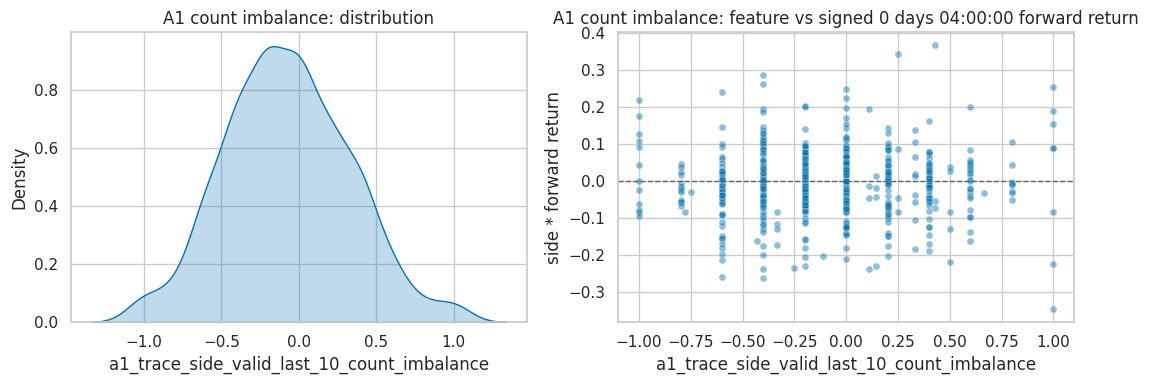

A1 count imbalance: time series on SB00007 (224 points)


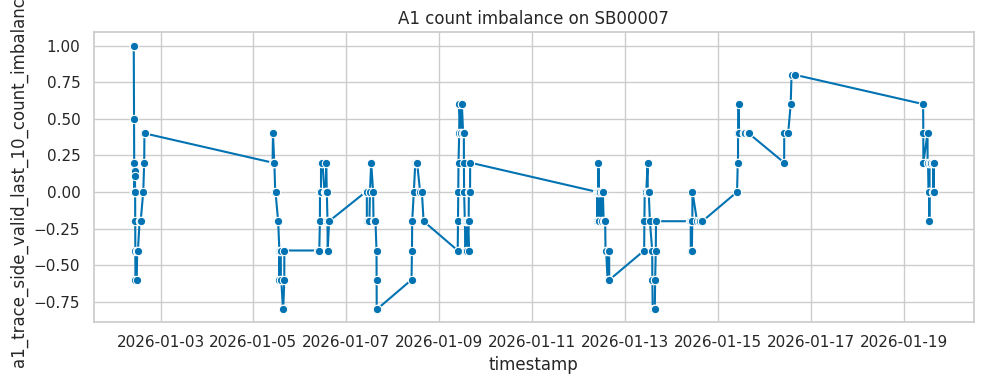

In [6]:
feature = PRIMARY_FEATURES["A1"]
plot_feature_distribution(analysis, feature, "A1 count imbalance")
plot_feature_timeseries(analysis, feature, "A1 count imbalance")

## A2 — Notional imbalance

Signed notional pressure in the last 10 prints.
Large-print reversal plants temporary price moves after high-notional events, so this feature is most informative when conditioned on print size.

A2 notional imbalance: 582 / 592 events, 31 large prints
A2 notional imbalance: plotting 582 events with finite a2_trace_side_valid_last_10_raw_notional_imbalance


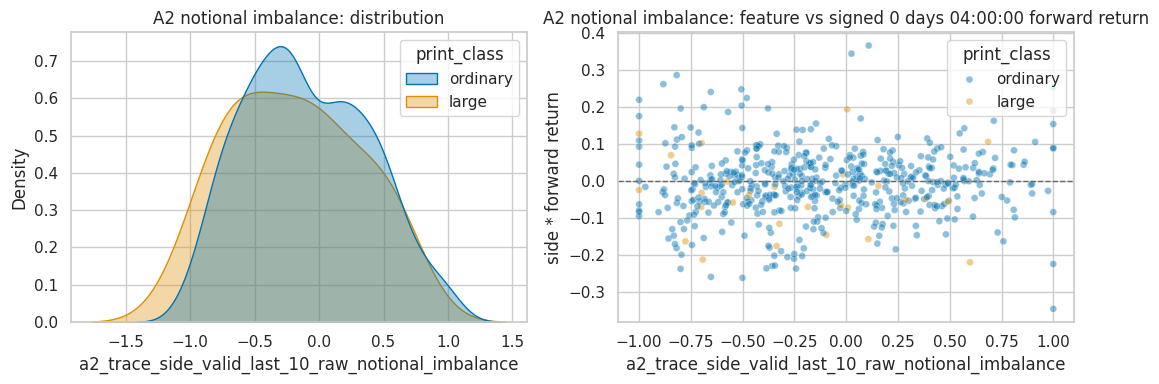

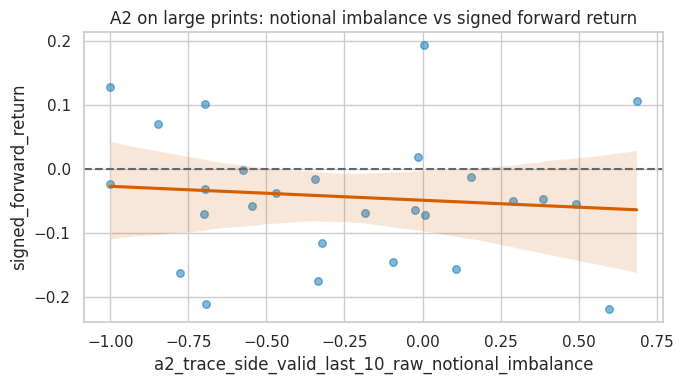

Large-print regplot: 27 points


In [7]:
if "analysis" not in globals():
    raise RuntimeError("Run the data-loading and feature cells above first.")

feature = PRIMARY_FEATURES["A2"]
print(
    f"A2 notional imbalance: {analysis[feature].notna().sum():,} / {len(analysis):,} events, "
    f"{int(analysis['is_large_print'].sum())} large prints"
)

plot_feature_distribution(analysis, feature, "A2 notional imbalance", hue="print_class")

large_prints = analysis[analysis["is_large_print"]].dropna(subset=[feature, "signed_forward_return"])
if large_prints.empty:
    print("No large prints with finite feature and forward return in this sample.")
else:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.regplot(
        data=large_prints,
        x=feature,
        y="signed_forward_return",
        scatter_kws={"alpha": 0.5, "s": 30},
        line_kws={"color": PALETTE[3]},
        ax=ax,
    )
    ax.axhline(0.0, color="0.4", linestyle="--")
    ax.set_title("A2 on large prints: notional imbalance vs signed forward return")
    plt.tight_layout()
    plt.show()
    print(f"Large-print regplot: {len(large_prints):,} points")

## A3 — Buy/sell intensity pressure

Elapsed-time EWMA buy and sell intensities and their log ratio.
Under Hawkes sign persistence, buy intensity should stay elevated after buy prints (and symmetrically for sells).

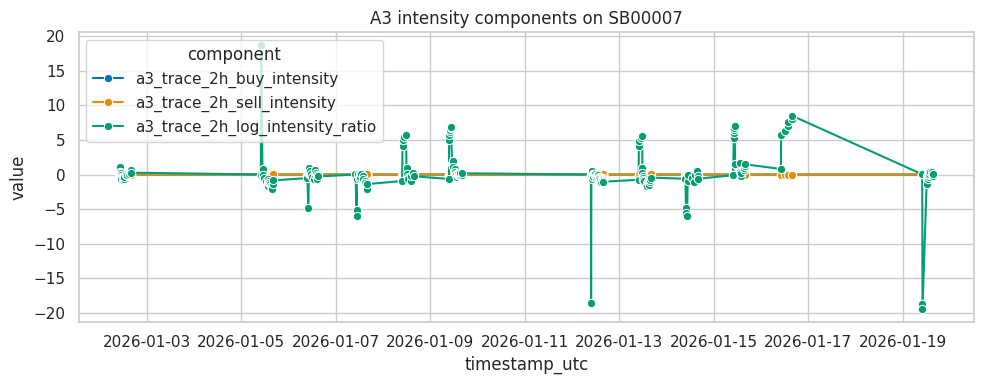

A3 log intensity ratio: plotting 561 events with finite a3_trace_2h_log_intensity_ratio


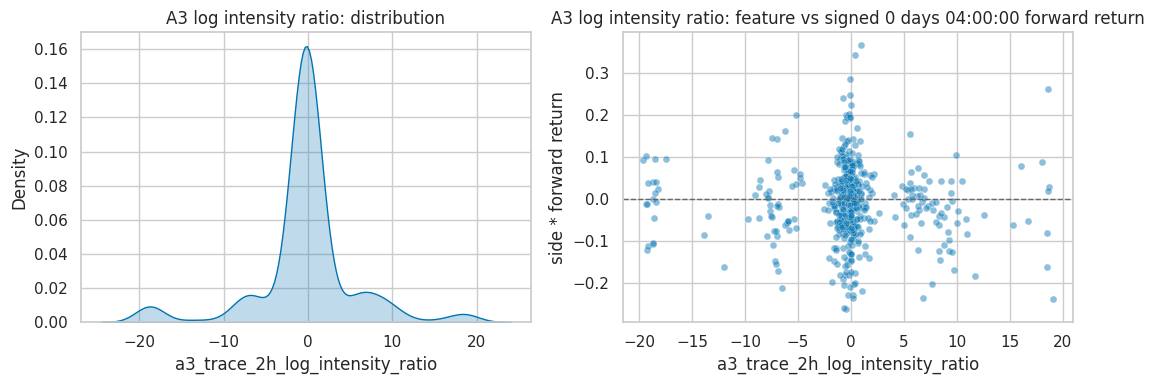

In [8]:
bond_id = analysis["synthetic_bond_id"].value_counts().idxmax()
bond_frame = analysis[analysis["synthetic_bond_id"] == bond_id].sort_values("timestamp_utc")
intensity_cols = ["a3_trace_2h_buy_intensity", "a3_trace_2h_sell_intensity", PRIMARY_FEATURES["A3"]]
melted = bond_frame.melt(
    id_vars=["timestamp_utc"],
    value_vars=[col for col in intensity_cols if col in bond_frame.columns],
    var_name="component",
    value_name="value",
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=melted, x="timestamp_utc", y="value", hue="component", marker="o", ax=ax)
ax.set_title(f"A3 intensity components on {bond_id}")
plt.tight_layout()
plt.show()

plot_feature_distribution(analysis, PRIMARY_FEATURES["A3"], "A3 log intensity ratio")

## A4 — Last-side persistence

Fraction of the last 10 same-bond prints sharing the most recent side.
Values above 0.5 indicate sign persistence from Hawkes same-side branching.

A4 same-side fraction: plotting 582 events with finite a4_trace_last_10_fraction_same_as_last


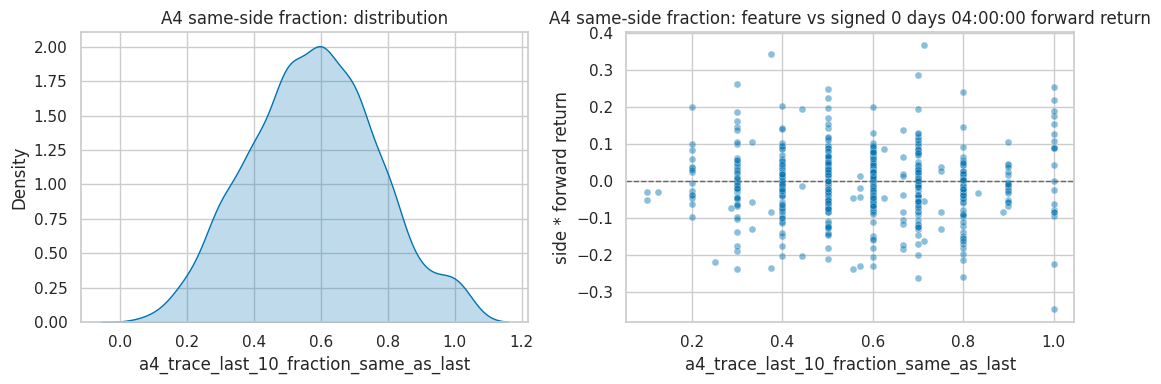

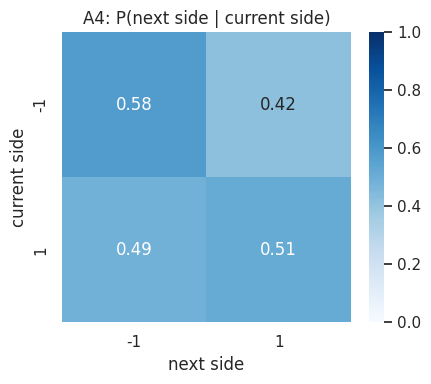

In [9]:
feature = PRIMARY_FEATURES["A4"]
plot_feature_distribution(analysis, feature, "A4 same-side fraction")

ordered = analysis.sort_values(["synthetic_bond_id", "timestamp_utc"])
transitions: list[tuple[int, int]] = []
for _, group in ordered.groupby("synthetic_bond_id", sort=False):
  sides = group["side"].astype(int).tolist()
  transitions.extend(zip(sides[:-1], sides[1:]))
transition = pd.DataFrame(transitions, columns=["current_side", "next_side"])
matrix = pd.crosstab(transition["current_side"], transition["next_side"], normalize="index")

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("A4: P(next side | current side)")
ax.set_xlabel("next side")
ax.set_ylabel("current side")
plt.tight_layout()
plt.show()

## A5 — Activity surprise

Recent event count minus the bond's own same-hour baseline, scaled by historical dispersion.
Spikes appear around Hawkes immigrant clusters and offspring bursts.

A5 activity surprise: plotting 355 events with finite a5_trace_2h_event_count_surprise


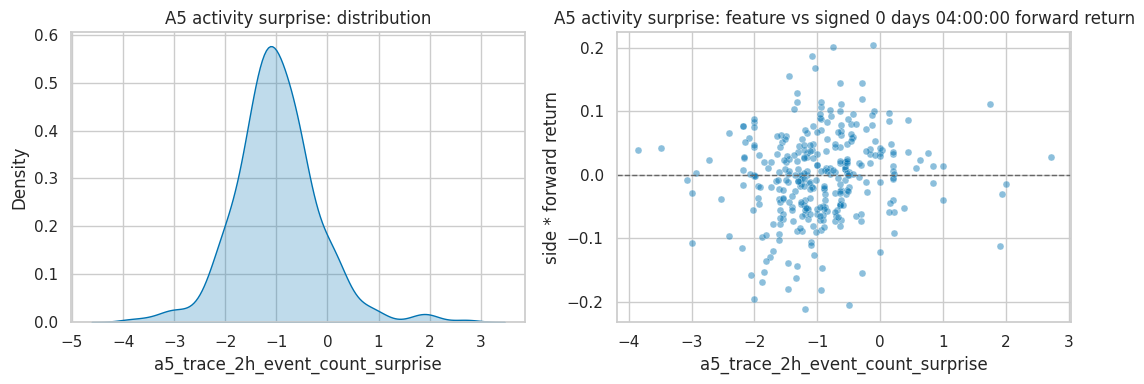

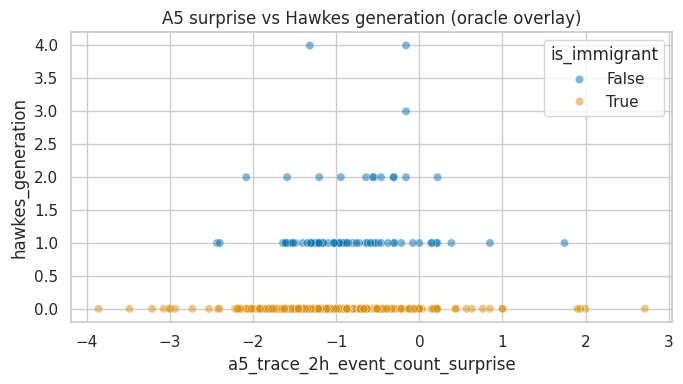

In [10]:
feature = PRIMARY_FEATURES["A5"]
plot_feature_distribution(analysis, feature, "A5 activity surprise")

surprise_frame = analysis.dropna(subset=[feature]).copy()
if not surprise_frame.empty:
  fig, ax = plt.subplots(figsize=(7, 4))
  sns.scatterplot(
    data=surprise_frame,
    x=feature,
    y="hawkes_generation",
    hue="is_immigrant" if "is_immigrant" in surprise_frame.columns else None,
    alpha=0.5,
    ax=ax,
  )
  ax.set_title("A5 surprise vs Hawkes generation (oracle overlay)")
  plt.tight_layout()
  plt.show()

## A6 — Spread-conditioned flow pressure

Signed notional flow in the last five prints.
Composite spread fields are unavailable in public synthetic output, so we visualize the flow component and its interaction with forward returns.

A6 flow pressure: plotting 582 events with finite a6_trace_last_5_flow_pressure


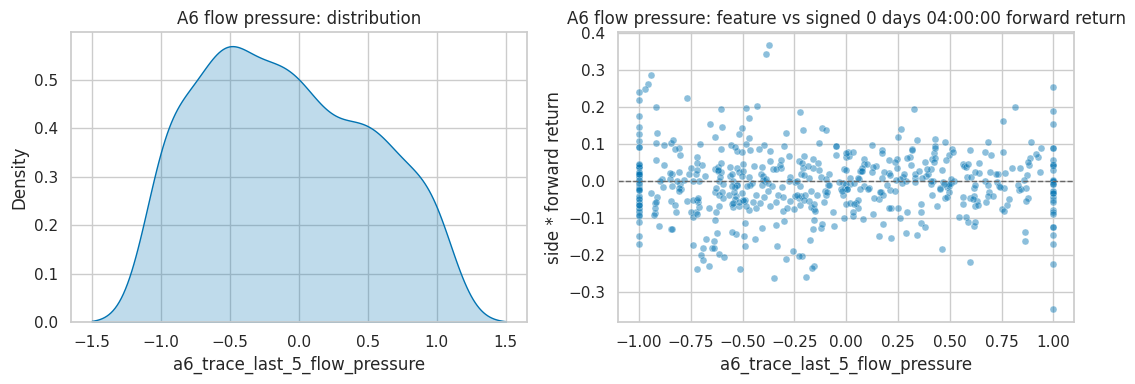

/tmp/ipykernel_1101705/1927544690.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=leadlag, x="print_class", y=feature, ax=ax, palette="pastel")


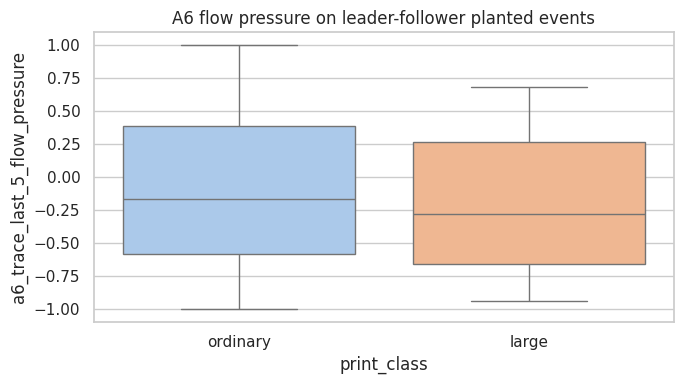

In [11]:
feature = PRIMARY_FEATURES["A6"]
plot_feature_distribution(analysis, feature, "A6 flow pressure")

leadlag = analysis[analysis["planted_effect_ids"].fillna("").str.contains("leader_follower")]
if not leadlag.empty:
  fig, ax = plt.subplots(figsize=(7, 4))
  sns.boxplot(data=leadlag, x="print_class", y=feature, ax=ax, palette="pastel")
  ax.set_title("A6 flow pressure on leader-follower planted events")
  plt.tight_layout()
  plt.show()

## A16 — RFQ scarcity and disagreement

These features require RFQ responder metadata.
Public BondSim trace output does not include RFQs, so the notebook reports coverage instead of a directional plot.

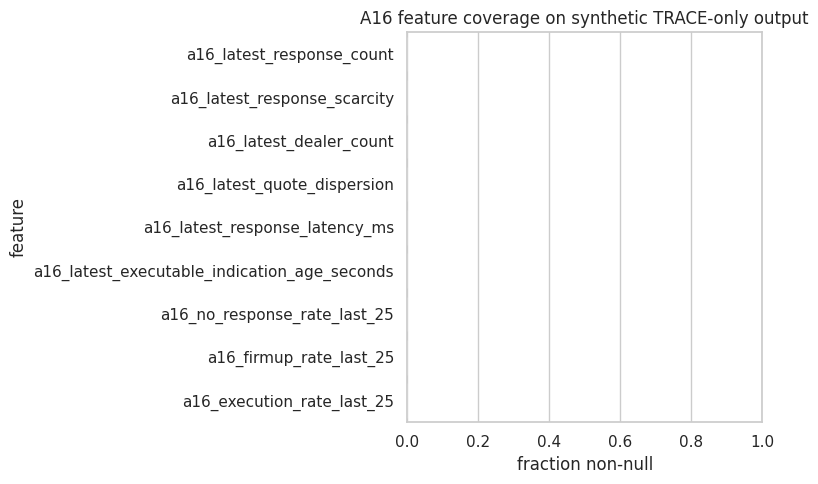

In [12]:
a16_cols = [col for col in alpha_frames["A16"].columns if col.startswith("a16_")]
coverage = (
  alpha_frames["A16"][a16_cols]
  .notna()
  .mean()
  .sort_values(ascending=True)
  .rename("non_null_fraction")
  .reset_index()
  .rename(columns={"index": "feature"})
)
coverage["feature"] = coverage["feature"].astype(str)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=coverage, y="feature", x="non_null_fraction", ax=ax, color=PALETTE[2])
ax.set_xlim(0, 1)
ax.set_title("A16 feature coverage on synthetic TRACE-only output")
ax.set_xlabel("fraction non-null")
plt.tight_layout()
plt.show()

## Summary — primary feature vs signed forward return

One panel per alpha. Points are individual trade events.

alpha                                            feature  corr_signed_fwd   n
   A1        a1_trace_side_valid_last_10_count_imbalance         0.018637 538
   A2 a2_trace_side_valid_last_10_raw_notional_imbalance         0.042794 538
   A3                    a3_trace_2h_log_intensity_ratio        -0.041292 518
   A4             a4_trace_last_10_fraction_same_as_last        -0.025190 538
   A5                   a5_trace_2h_event_count_surprise         0.134279 319
   A6                      a6_trace_last_5_flow_pressure        -0.003234 538
  A16                       a16_latest_response_scarcity              NaN   0


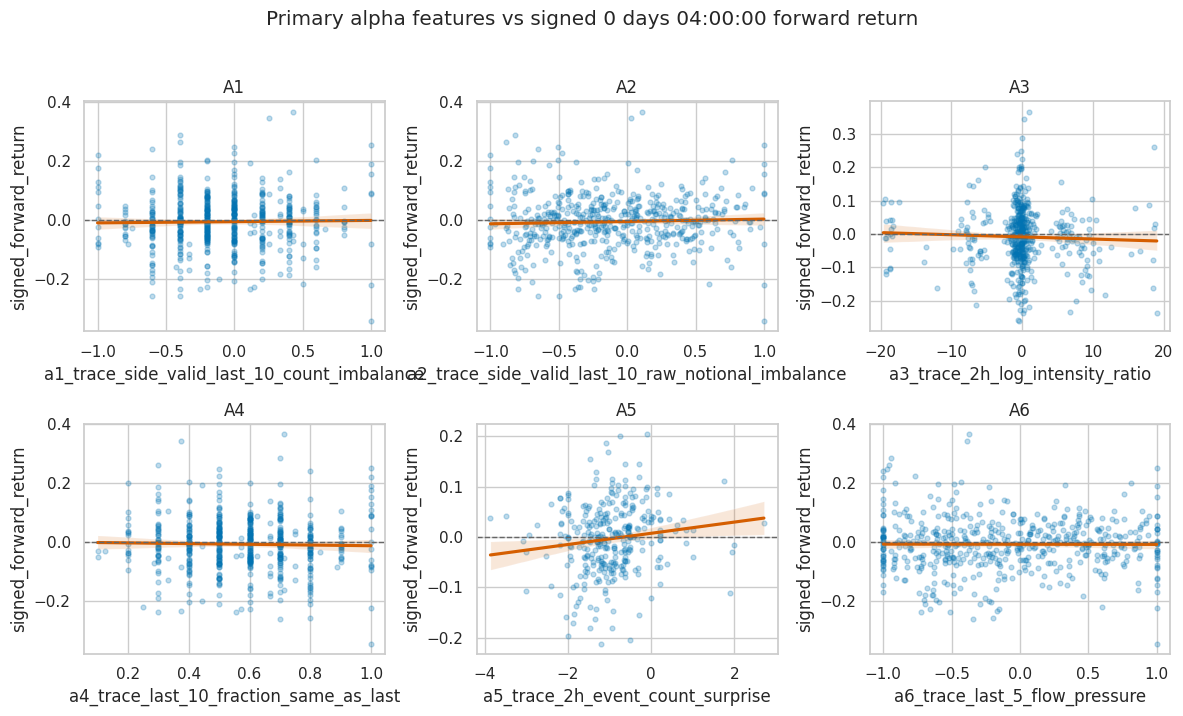

In [13]:
summary_rows = []
for alpha_id, feature in PRIMARY_FEATURES.items():
    valid = analysis[[feature, "signed_forward_return"]].dropna()
    corr = valid[feature].corr(valid["signed_forward_return"]) if len(valid) > 5 else np.nan
    summary_rows.append({"alpha": alpha_id, "feature": feature, "corr_signed_fwd": corr, "n": len(valid)})
summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

plot_alphas = [alpha_id for alpha_id, feature in PRIMARY_FEATURES.items() if analysis[feature].notna().sum() > 20]
n_cols = 3
n_rows = int(np.ceil(len(plot_alphas) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.5 * n_rows))
axes_flat = np.array(axes).reshape(-1)
for ax, alpha_id in zip(axes_flat, plot_alphas, strict=False):
    feature = PRIMARY_FEATURES[alpha_id]
    sns.regplot(
        data=analysis.dropna(subset=[feature, "signed_forward_return"]),
        x=feature,
        y="signed_forward_return",
        scatter_kws={"alpha": 0.25, "s": 12},
        line_kws={"color": PALETTE[3]},
        ax=ax,
    )
    ax.axhline(0.0, color="0.4", linestyle="--", linewidth=1)
    ax.set_title(alpha_id)
for ax in axes_flat[len(plot_alphas):]:
    ax.axis("off")
fig.suptitle(f"Primary alpha features vs signed {HORIZON} forward return", y=1.02)
plt.tight_layout()
plt.show()